#Data Ingestion
#Importing all necessary librariesp

In [41]:
!pip install numpy pandas matplotlib seaborn
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:

from zipfile import ZipFile

In [43]:



path = r"C:\Users\User\Desktop\new_work\archive.zip"

In [44]:
with ZipFile(path, "r") as f:
    f.printdir()

File Name                                             Modified             Size
fruit_classification_dataset.csv               2025-10-30 15:45:34       408671


In [45]:

from zipfile import ZipFile

with ZipFile(path, "r") as f:
    with f.open("fruit_classification_dataset.csv") as file:
        df = pd.read_csv(file)

print(df.head())

   size (cm)  shape  weight (g)  avg_price (₹)   color  taste     fruit_name
0       25.4  round      3089.2          137.1   green  sweet     watermelon
1       24.6  round      3283.9          163.8   green  sweet     watermelon
2        7.8  round       319.0           91.3   green  sweet  custard apple
3       20.0   oval      1607.0           85.7  orange  sweet         papaya
4       10.2   long       131.5           37.8  yellow  sweet         banana


PREMILARY DATA ANALYSIS

In [46]:
df.columns

Index(['size (cm)', 'shape', 'weight (g)', 'avg_price (₹)', 'color', 'taste',
       'fruit_name'],
      dtype='str')

In [47]:
df.shape

(10000, 7)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  str    
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  str    
 5   taste          10000 non-null  str    
 6   fruit_name     10000 non-null  str    
dtypes: float64(3), str(4)
memory usage: 547.0 KB


In [49]:
df.duplicated().sum()

np.int64(246)

In [50]:
df= df.drop_duplicates()

In [51]:
df.shape

(9754, 7)

EXPLORATORY DATA ANALYSIS

In [52]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
size (cm),9754.0,8.611195,6.372831,0.9,4.0,7.3,10.20,27.5
weight (g),9754.0,466.779209,737.286782,4.5,47.6,177.2,375.65,3299.8
avg_price (₹),9754.0,78.423621,38.324394,9.0,49.0,76.3,101.70,165.0


In [53]:
categorical_col= df.select_dtypes(include='object').columns
categorical_col

C:\Users\User\AppData\Local\Temp\ipykernel_13292\259231115.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col= df.select_dtypes(include='object').columns


Index(['shape', 'color', 'taste', 'fruit_name'], dtype='str')

In [54]:
from sklearn.preprocessing import LabelEncoder

shape = ['round', 'oval', 'long']
df['shape'] = df['shape'].str.strip()
order = LabelEncoder()
df['shape'] = order.fit_transform(df['shape'])
print(f"Shape categories: {shape}")
print(f"Encoded values: {df['shape'].unique()}")

Shape categories: ['round', 'oval', 'long']
Encoded values: [2 1 0]


In [55]:
taste = ['sweet','tangy','sour']

df['taste'] = df['taste'].str.strip()
order = LabelEncoder()
df['taste'] = order.fit_transform(df['taste'])
print(f"Taste categories: {taste}")
print(f"Encoded values: {df['taste'].unique()}")

Taste categories: ['sweet', 'tangy', 'sour']
Encoded values: [1 2 0]


In [56]:
df.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,2,3089.2,137.1,green,1,watermelon
1,24.6,2,3283.9,163.8,green,1,watermelon
2,7.8,2,319.0,91.3,green,1,custard apple
3,20.0,1,1607.0,85.7,orange,1,papaya
4,10.2,0,131.5,37.8,yellow,1,banana


In [57]:
numerical_col= df.select_dtypes(include='number').columns
numerical_col

Index(['size (cm)', 'shape', 'weight (g)', 'avg_price (₹)', 'taste'], dtype='str')

In [58]:
for col in categorical_col:
    df[col].value_counts()
    print(df[col].value_counts())
    print("="*30)
    print()

shape
2    4796
1    4456
0     502
Name: count, dtype: int64

color
green     2029
red       1920
brown     1541
yellow    1002
orange     993
pink       991
purple     835
blue       443
Name: count, dtype: int64

taste
1    7261
2    2012
0     481
Name: count, dtype: int64

fruit_name
pomegranate      534
pear             534
pineapple        533
custard apple    516
papaya           509
kiwi             506
banana           502
coconut          502
mango            500
watermelon       498
dragon fruit     496
lychee           495
apple            492
plum             489
orange           484
guava            481
cherry           462
blueberry        443
strawberry       432
grape            346
Name: count, dtype: int64



In [59]:
for col in numerical_col:
    df[col].value_counts()
    print(df[col].value_counts())
    print("="*30)
    print()

size (cm)
1.0     357
1.1     219
0.9     213
2.8     173
3.1     166
       ... 
21.7      6
27.4      5
24.9      5
27.5      4
25.3      4
Name: count, Length: 227, dtype: int64

shape
2    4796
1    4456
0     502
Name: count, dtype: int64

weight (g)
5.2       89
5.1       84
4.8       82
5.4       78
5.0       78
          ..
3202.0     1
1358.7     1
1519.8     1
177.0      1
1165.0     1
Name: count, Length: 4168, dtype: int64

avg_price (₹)
63.8     26
37.1     25
65.4     25
76.8     23
64.6     23
         ..
140.4     1
53.5      1
141.3     1
47.3      1
162.4     1
Name: count, Length: 1355, dtype: int64

taste
1    7261
2    2012
0     481
Name: count, dtype: int64



FEATURE ENCODING

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Split first
X = df.drop(columns=["fruit_name"])
y = df["fruit_name"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# 2. Choose a scaler (StandardScaler is fine; RandomForest doesn't need scaling, but if you use it, be consistent)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on training data only, then transform both train and test
numerical_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']   # only the continuous features
# Note: shape, color, taste are already encoded integers – they should NOT be scaled!
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [61]:
# # let scale the numerical columns using minmax scaler 
# from sklearn.preprocessing import MinMaxScaler


# scaler= MinMaxScaler()
# X[numerical_col]= scaler.fit_transform(X[numerical_col])

# # let scale the numerical columns in test data too
# df[numerical_col]= scaler.transform(df[numerical_col])

In [62]:
print("shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

shape of Training set :  (6827, 6)
Shape of test set :  (2927, 6)
Percentage of classes in training set:
fruit_name
pear             0.054782
pomegranate      0.054782
pineapple        0.054636
custard apple    0.052878
papaya           0.052146
kiwi             0.051853
banana           0.051414
coconut          0.051414
mango            0.051267
watermelon       0.051121
lychee           0.050828
dragon fruit     0.050828
apple            0.050388
plum             0.050095
orange           0.049656
guava            0.049363
cherry           0.047312
blueberry        0.045408
strawberry       0.044383
grape            0.035447
Name: proportion, dtype: float64
Percentage of classes in test set:
fruit_name
pear             0.054663
pomegranate      0.054663
pineapple        0.054663
custard apple    0.052955
papaya           0.052272
kiwi             0.051930
banana           0.051589
coconut          0.051589
mango            0.051247
watermelon       0.050905
dragon fruit     0.050905

In [63]:
# # initialize models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=234),
    "Random Forest": RandomForestClassifier(random_state=234),
    "Decision Tree": DecisionTreeClassifier(random_state=234),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()

}

In [64]:
# # Initialize a dictionary to store the models

# from sklearn.metrics import accuracy_score
# from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


# results = {}
# for model_name, model in models.items():
#     print(f'Training {model_name}...')
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     accuracy = accuracy_score(y_test, y_pred)
#     results[model_name] = accuracy
#     print(f'{model_name} Accuracy: {accuracy}')

#     # Include the confusion matrix
#     cm = confusion_matrix(y_test, y_pred)
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm)

#     # plot with model name as title
#     disp.plot(cmap='Greens')
#     plt.title(f'Confusion Matrix - {model_name}')
#     plt.show()

In [65]:
print(df.head())
print(df.info())

   size (cm)  shape  weight (g)  avg_price (₹)   color  taste     fruit_name
0       25.4      2      3089.2          137.1   green      1     watermelon
1       24.6      2      3283.9          163.8   green      1     watermelon
2        7.8      2       319.0           91.3   green      1  custard apple
3       20.0      1      1607.0           85.7  orange      1         papaya
4       10.2      0       131.5           37.8  yellow      1         banana
<class 'pandas.DataFrame'>
Index: 9754 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      9754 non-null   float64
 1   shape          9754 non-null   int64  
 2   weight (g)     9754 non-null   float64
 3   avg_price (₹)  9754 non-null   float64
 4   color          9754 non-null   str    
 5   taste          9754 non-null   int64  
 6   fruit_name     9754 non-null   str    
dtypes: float64(3), int64(2), str(2)
memory usage: 6

In [66]:
print(df.isnull().sum())

size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64


In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [68]:
X = df.drop('fruit_name', axis=1)   # replace 'label' with your target column
y = df["fruit_name"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [70]:
print(X_train.dtypes)

size (cm)        float64
shape              int64
weight (g)       float64
avg_price (₹)    float64
color                str
taste              int64
dtype: object


In [71]:
print(X_train.head())

      size (cm)  shape  weight (g)  avg_price (₹)  color  taste
3316        2.1      2        14.1           50.1   pink      1
7045        4.9      1        78.7          104.3  brown      2
4702        4.9      1        70.3           91.1  brown      2
6564        8.3      1       196.7           69.5  green      1
6287        8.8      1       193.2           63.9  green      1


In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X_train.columns:
    if X_train[column].dtype == 'object':
        X_train[column] = le.fit_transform(X_train[column])

for column in X_test.columns:
    if X_test[column].dtype == 'object':
        X_test[column] = le.fit_transform(X_test[column])

In [73]:
# model.fit(X_train, y_train)

In [74]:
#Checking for missing value
print(X_train.isnull().sum())

size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
dtype: int64


In [75]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [76]:
# checking for invalid values
import numpy as np


#fix
X_train.replace([np.inf, -np.inf], 0, inplace=True)
X_test.replace([np.inf, -np.inf], 0, inplace=True)

,size (cm),shape,weight (g),avg_price (₹),color,taste
4597,9.4,1,246.7,121.5,yellow,1
4756,10.2,0,115.4,38.1,yellow,1
1621,2.9,1,20.4,62.5,red,1
9806,7.8,2,313.0,91.8,green,1
3582,7.5,1,180.0,64.9,green,1
...,...,...,...,...,...,...
3206,6.6,2,242.3,126.2,red,1
2785,8.8,2,309.7,97.5,green,1
5244,8.5,1,174.6,65.5,green,1
3032,21.2,1,1613.1,73.0,orange,1


In [77]:
# checking out for unique values
print(y_train.unique())

<StringArray>
[       'lychee',          'kiwi',          'pear',        'papaya',
   'pomegranate',    'watermelon',        'banana',  'dragon fruit',
 'custard apple',         'grape',          'plum',        'orange',
     'blueberry',    'strawberry',         'guava',       'coconut',
         'mango',         'apple',     'pineapple',        'cherry']
Length: 20, dtype: str


In [78]:
le_y = LabelEncoder()

y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)

In [79]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create fresh copy to avoid re-encoding already encoded columns
df_processed = df.copy()

# Encode shape safely
shape_le = LabelEncoder()
if df_processed['shape'].dtype == 'object':
    df_processed['shape'] = shape_le.fit_transform(df_processed['shape'].astype(str).str.strip())
else:
    df_processed['shape'] = shape_le.fit_transform(df_processed['shape'])

print("Shape categories:", shape_le.classes_)

# Encode taste safely
taste_le = LabelEncoder()
if df_processed['taste'].dtype == 'object':
    df_processed['taste'] = taste_le.fit_transform(df_processed['taste'].astype(str).str.strip())
else:
    df_processed['taste'] = taste_le.fit_transform(df_processed['taste'])

print("Taste categories:", taste_le.classes_)

# Encode color safely
color_le = LabelEncoder()
if df_processed['color'].dtype == 'object':
    df_processed['color'] = color_le.fit_transform(df_processed['color'].astype(str).str.strip())
else:
    df_processed['color'] = color_le.fit_transform(df_processed['color'])

print("Color categories:", color_le.classes_)

# Encode target variable
target_le = LabelEncoder()
df_processed['fruit_name_encoded'] = target_le.fit_transform(df_processed['fruit_name'])

print("\nTarget classes:",
      dict(zip(target_le.classes_,
               target_le.transform(target_le.classes_))))

# Prepare features and target
X = df_processed.drop(columns=['fruit_name', 'fruit_name_encoded'])
y = df_processed['fruit_name_encoded']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")

# Scale numerical columns
numerical_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features scaled successfully.")


Shape categories: [0 1 2]
Taste categories: [0 1 2]
Color categories: ['blue' 'brown' 'green' 'orange' 'pink' 'purple' 'red' 'yellow']

Target classes: {'apple': np.int64(0), 'banana': np.int64(1), 'blueberry': np.int64(2), 'cherry': np.int64(3), 'coconut': np.int64(4), 'custard apple': np.int64(5), 'dragon fruit': np.int64(6), 'grape': np.int64(7), 'guava': np.int64(8), 'kiwi': np.int64(9), 'lychee': np.int64(10), 'mango': np.int64(11), 'orange': np.int64(12), 'papaya': np.int64(13), 'pear': np.int64(14), 'pineapple': np.int64(15), 'plum': np.int64(16), 'pomegranate': np.int64(17), 'strawberry': np.int64(18), 'watermelon': np.int64(19)}

Train shape: (6827, 6), Test shape: (2927, 6)
Numerical features scaled successfully.



Class distribution in training set:
fruit_name_encoded
0     0.050388
1     0.051414
2     0.045408
3     0.047312
4     0.051414
5     0.052878
6     0.050828
7     0.035447
8     0.049363
9     0.051853
10    0.050828
11    0.051267
12    0.049656
13    0.052146
14    0.054782
15    0.054636
16    0.050095
17    0.054782
18    0.044383
19    0.051121
Name: proportion, dtype: float64

Training Logistic Regression...
Logistic Regression Accuracy: 1.0000
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00       148
       banana       1.00      1.00      1.00       151
    blueberry       1.00      1.00      1.00       133
       cherry       1.00      1.00      1.00       139
      coconut       1.00      1.00      1.00       151
custard apple       1.00      1.00      1.00       155
 dragon fruit       1.00      1.00      1.00       149
        grape       1.00      1.00      1.00       104
        guava       1.00      1.00      1.00 

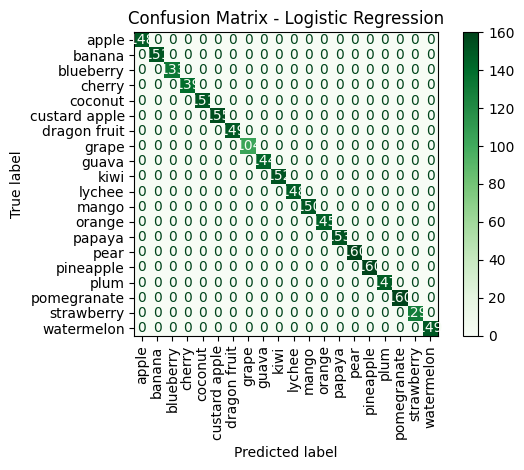


Training Random Forest...
Random Forest Accuracy: 1.0000
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00       148
       banana       1.00      1.00      1.00       151
    blueberry       1.00      1.00      1.00       133
       cherry       1.00      1.00      1.00       139
      coconut       1.00      1.00      1.00       151
custard apple       1.00      1.00      1.00       155
 dragon fruit       1.00      1.00      1.00       149
        grape       1.00      1.00      1.00       104
        guava       1.00      1.00      1.00       144
         kiwi       1.00      1.00      1.00       152
       lychee       1.00      1.00      1.00       148
        mango       1.00      1.00      1.00       150
       orange       1.00      1.00      1.00       145
       papaya       1.00      1.00      1.00       153
         pear       1.00      1.00      1.00       160
    pineapple       1.00      1.00      1.00       160
      

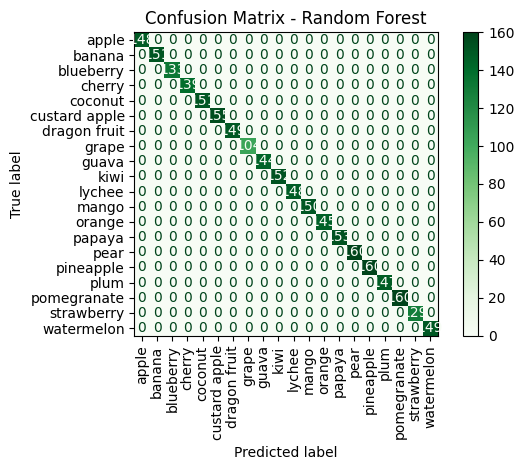


Training Decision Tree...
Decision Tree Accuracy: 1.0000
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00       148
       banana       1.00      1.00      1.00       151
    blueberry       1.00      1.00      1.00       133
       cherry       1.00      1.00      1.00       139
      coconut       1.00      1.00      1.00       151
custard apple       1.00      1.00      1.00       155
 dragon fruit       1.00      1.00      1.00       149
        grape       1.00      1.00      1.00       104
        guava       1.00      1.00      1.00       144
         kiwi       1.00      1.00      1.00       152
       lychee       1.00      1.00      1.00       148
        mango       1.00      1.00      1.00       150
       orange       1.00      1.00      1.00       145
       papaya       1.00      1.00      1.00       153
         pear       1.00      1.00      1.00       160
    pineapple       1.00      1.00      1.00       160
      

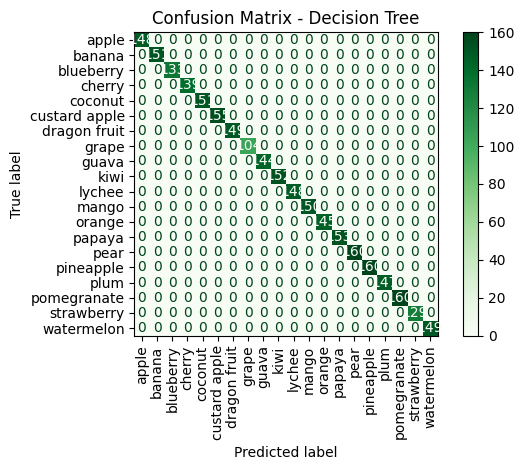


Training KNN...
KNN Accuracy: 1.0000
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00       148
       banana       1.00      1.00      1.00       151
    blueberry       1.00      1.00      1.00       133
       cherry       1.00      1.00      1.00       139
      coconut       1.00      1.00      1.00       151
custard apple       1.00      1.00      1.00       155
 dragon fruit       1.00      1.00      1.00       149
        grape       1.00      1.00      1.00       104
        guava       1.00      1.00      1.00       144
         kiwi       1.00      1.00      1.00       152
       lychee       1.00      1.00      1.00       148
        mango       1.00      1.00      1.00       150
       orange       1.00      1.00      1.00       145
       papaya       1.00      1.00      1.00       153
         pear       1.00      1.00      1.00       160
    pineapple       1.00      1.00      1.00       160
         plum       1.00  

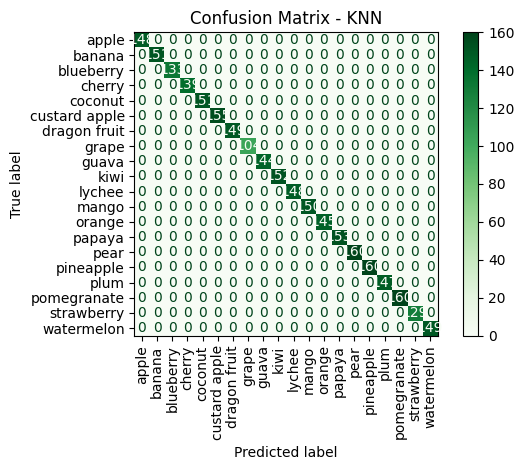


Training SVM...
SVM Accuracy: 1.0000
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00       148
       banana       1.00      1.00      1.00       151
    blueberry       1.00      1.00      1.00       133
       cherry       1.00      1.00      1.00       139
      coconut       1.00      1.00      1.00       151
custard apple       1.00      1.00      1.00       155
 dragon fruit       1.00      1.00      1.00       149
        grape       1.00      1.00      1.00       104
        guava       1.00      1.00      1.00       144
         kiwi       1.00      1.00      1.00       152
       lychee       1.00      1.00      1.00       148
        mango       1.00      1.00      1.00       150
       orange       1.00      1.00      1.00       145
       papaya       1.00      1.00      1.00       153
         pear       1.00      1.00      1.00       160
    pineapple       1.00      1.00      1.00       160
         plum       1.00  

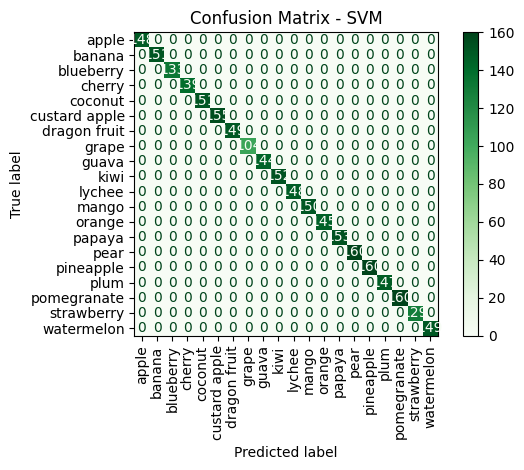


Best model: LogisticRegression with accuracy 1.0000


In [81]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Check class distribution after split
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).sort_index())

# %% [markdown]
# ## Model Training & Selection

# %%
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=234),
    "Random Forest": RandomForestClassifier(random_state=234),
    "Decision Tree": DecisionTreeClassifier(random_state=234),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=234)
}

results = {}
best_model = None
best_accuracy = 0.0

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[model_name] = acc
    print(f"{model_name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_le.classes_, zero_division=0))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_le.classes_)
    disp.plot(cmap='Greens', xticks_rotation='vertical')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

print("\n" + "="*50)
print(f"Best model: {best_model.__class__.__name__} with accuracy {best_accuracy:.4f}")
print("="*50)



Final accuracy of LogisticRegression: 1.0000

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00       148
       banana       1.00      1.00      1.00       151
    blueberry       1.00      1.00      1.00       133
       cherry       1.00      1.00      1.00       139
      coconut       1.00      1.00      1.00       151
custard apple       1.00      1.00      1.00       155
 dragon fruit       1.00      1.00      1.00       149
        grape       1.00      1.00      1.00       104
        guava       1.00      1.00      1.00       144
         kiwi       1.00      1.00      1.00       152
       lychee       1.00      1.00      1.00       148
        mango       1.00      1.00      1.00       150
       orange       1.00      1.00      1.00       145
       papaya       1.00      1.00      1.00       153
         pear       1.00      1.00      1.00       160
    pineapple       1.00      1.00      1.00    

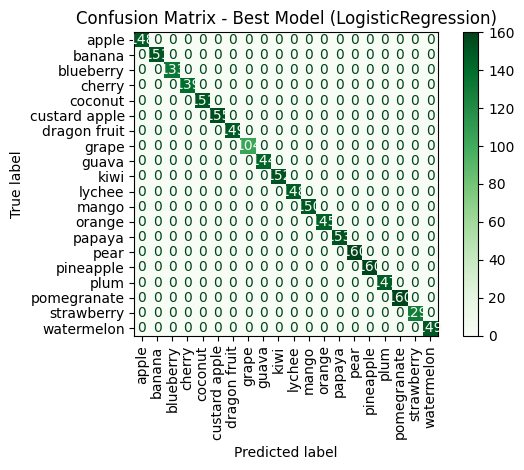

All artifacts saved in: C:\Users\User\Desktop\new_work\model


In [82]:
# %% [markdown]
# ## Evaluate Best Model on Test Set

# %%
y_pred_best = best_model.predict(X_test)
print(f"\nFinal accuracy of {best_model.__class__.__name__}: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_best, target_names=target_le.classes_))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(cm_best, display_labels=target_le.classes_)
disp_best.plot(cmap='Greens', xticks_rotation='vertical')
plt.title(f'Confusion Matrix - Best Model ({best_model.__class__.__name__})')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Save Model and Preprocessing Artifacts

# %%
from pathlib import Path

file_path = Path("dataset.csv")

model_dir = Path('model')
model_dir.mkdir(parents=True, exist_ok=True)

import joblib

joblib.dump(best_model, model_dir / 'model.pkl')
joblib.dump(scaler, model_dir / 'scaler.pkl')
joblib.dump(target_le, model_dir / 'target_encoder.pkl')
joblib.dump(shape_le, model_dir / 'shape_encoder.pkl')
joblib.dump(taste_le, model_dir / 'taste_encoder.pkl')
joblib.dump(color_le, model_dir / 'color_encoder.pkl')

print(f"All artifacts saved in: {model_dir.resolve()}")

In [83]:
import joblib
from pathlib import Path

model_dir = Path('model')
model_dir.mkdir(parents=True, exist_ok=True)

# Save the trained model and scaler
joblib.dump(best_model, model_dir / 'model.pkl')
joblib.dump(scaler, model_dir / 'scaler.pkl')

print(f'Artifacts saved in: {model_dir.resolve()}')


Artifacts saved in: C:\Users\User\Desktop\new_work\model
